In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [22]:
# Criando dataframe
df_aprovacao = pd.DataFrame({
    "Idade": [18, 20, 22, 21, 19, 23, 24, 20, 25, 19, 21, 22, 18, 23, 24],
    "HorasEstudo": [2, 5, 1, 4, 3, 6, 5, 2, 7, 3, 4, 1, 2, 6, 5],
    "Aprovado": ["Não", "Sim", "Não", "Sim", "Sim", "Sim", "Sim", "Não", "Sim", "Não", "Sim", "Não", "Não", "Sim", "Sim"]
})
df_aprovacao.columns = df_aprovacao.columns.str.lower()

# df_aprovacao = pd.get_dummies(df_aprovacao, columns=['aprovado'])

df_aprovacao['fl_aprovado'] = np.where(df_aprovacao['aprovado'] == 'Sim', 1, 0)

x = df_aprovacao[['idade', 'horasestudo']]
y = df_aprovacao[['fl_aprovado']]

In [38]:
from sklearn.model_selection import train_test_split
X_temp, X_holdout, y_temp, y_holdout = train_test_split(x, y, test_size=0.2, random_state=42)
x_train, x_teste, y_train, y_teste = train_test_split(X_temp, y_temp, test_size=0.3, random_state=42)



from sklearn.tree import DecisionTreeClassifier
arvore = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
arvore.fit(x_train, y_train)
# arvore.score(x_train, y_train)                # Os acertos no conjunto de treino é de 100%
arvore.score(x_teste, y_teste)                  # -- Na validação de teste o modelo está acertando 100% também
# arvore.score(X_holdout, y_holdout)            # Modelo aceita 66% em outro conjunto de dados

1.0

In [45]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
y_pred = arvore.predict(X_holdout)
print(classification_report(y_holdout, y_pred))


              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.00      0.00      0.00         0

    accuracy                           0.67         3
   macro avg       0.50      0.33      0.40         3
weighted avg       1.00      0.67      0.80         3



c:\Users\joth1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\joth1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\joth1\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capita

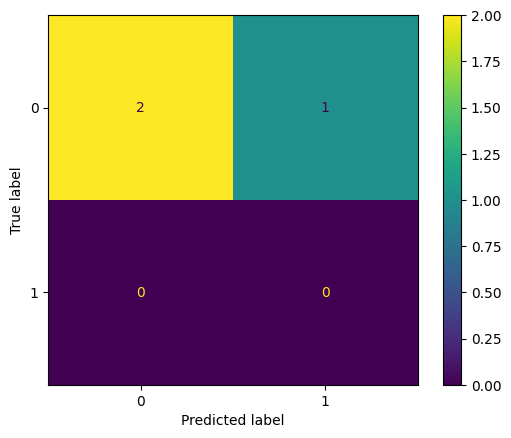

In [ ]:
# print("Accuracy:", accuracy_score(y_holdout, y_pred))

cm = confusion_matrix(y_holdout, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()



[Text(0.5, 0.75, 'x[1] <= 2.5\nentropy = 0.811\nsamples = 8\nvalue = [2, 6]'),
 Text(0.25, 0.25, 'entropy = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.75, 0.25, 'entropy = 0.0\nsamples = 6\nvalue = [0, 6]')]

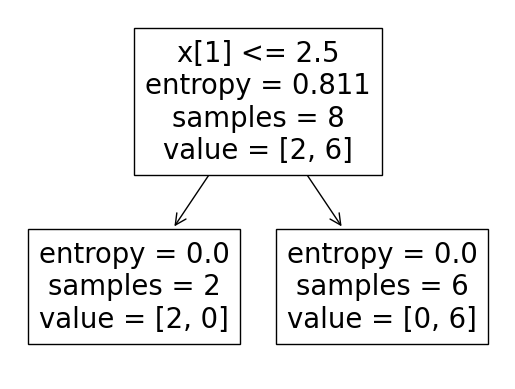

In [52]:
from sklearn import tree
tree.plot_tree(arvore)